# Insurance Fraud Detection Using Machine Learning

**End-to-End Data Science Workflow**

**Author:** Sevil Funda Polat

This notebook presents an end-to-end machine learning workflow for insurance fraud detection. It covers the complete data science pipeline, including business understanding, exploratory data analysis, data cleaning, feature engineering, feature selection, data preprocessing, model development, and model evaluation.

The analysis follows a structured workflow designed to minimize data leakage. Data exploration is performed before any target-based feature selection, while all feature selection and preprocessing steps are carried out using the training data only to ensure a fair and reliable evaluation of model performance.

#1.Business Understanding

## 1.1 Objective

Insurance fraud causes substantial financial losses for insurance companies each year. Detecting fraudulent claims accurately and as early as possible helps reduce operational costs, improve claim processing efficiency, and minimize financial risk.

The objective of this project is to develop a machine learning model capable of predicting whether an insurance claim is fraudulent based on customer information, policy characteristics, claim details, and incident-related variables.

The target variable is **fraud_reported**, which indicates whether a claim was classified as fraudulent (Y) or legitimate (N). Since the target has two possible outcomes, this is a **binary classification problem**.

## 1.2 Dataset

The analysis is based on the Insurance Claims dataset published on Mendeley Data.

**Source:** https://data.mendeley.com/datasets/992mh7dk9y/2

Each observation represents a single insurance claim submitted by a policyholder. The dataset contains customer demographics, policy information, claim characteristics, incident details, vehicle-related variables, and claim processing information collected during fraud investigations.

To protect customer privacy, personally identifiable information has been anonymized while preserving the relationships between variables for analytical purposes.

## 1.3 Business Problem

Insurance companies process thousands of claims every day, while only a small proportion are fraudulent. Investigating every claim manually is costly, time-consuming, and inefficient.

A predictive model can support fraud investigators by identifying claims that are more likely to be fraudulent, allowing investigative resources to be allocated more effectively. Such a model can reduce operational costs, accelerate claim processing, and improve decision-making.

This is a binary classification problem, where the objective is to distinguish fraudulent claims from legitimate ones.

## 1.4 Analytical Goals

The analysis aims to:

- Understand the structure and overall quality of the dataset.
- Identify data quality issues such as missing values, duplicates, outliers, and inconsistent records.
- Explore the distributions of numerical and categorical variables without introducing data leakage.
- Examine the target distribution to assess class imbalance.
- Prepare a clean dataset suitable for feature selection and machine learning.



## 1.5 Assumptions and Limitations

1. **Each record represents a single insurance claim rather than a unique customer.**

    Since the dataset does not include a unique customer identifier, it is not possible to verify whether multiple claims belong to the same policyholder. Therefore, the analysis is conducted at the claim level rather than the customer level. If multiple claims from the same policyholder are present, some customer characteristics may appear more than once, which could influence the distribution of certain variables.

2. **The dataset is assumed to be representative of historical insurance claims.**

   The analysis assumes that the observations are representative of the population of insurance claims and that the relationships observed in the dataset are relevant for developing a fraud detection model.

3. **The target labels are assumed to be correct.**

   The variable **fraud_reported** is assumed to accurately reflect the outcome of the fraud investigation. Any labeling errors would directly affect the performance and reliability of the predictive model.

4. **The analysis is limited to the available variables.**

   The analysis is limited to the variables available in the dataset. Potentially informative data, such as prior fraud history, customer behavioral information, or detailed investigation records, are not available. Therefore, the predictive performance of the model is inherently limited by the information contained in the dataset.

5. **Feature selection will be performed only on the training data.**

   Feature selection based on the relationship between predictor variables and the target variable will be performed only on the training data after the train-test split. This approach minimizes data leakage and ensures that the model is evaluated on previously unseen data, providing a more reliable estimate of its performance.

Business Understanding ✅

↓

Exploratory Data Analysis (EDA)

↓

Initial Data Cleaning

↓

Train-Test Split

↓

Feature Selection (Training only)

↓

Feature Engineering & Preprocessing

↓

Model Development

# 2. Exploratory Data Analysis (EDA)

The purpose of this section is to obtain an initial understanding of the dataset before any preprocessing or model development. The analysis focuses on exploring the structure of the data, assessing data quality, and examining the distributions of the variables.

At this stage, the analysis is purely descriptive. No target-based feature selection is performed in order to avoid data leakage. Any feature selection or preprocessing decisions based on the relationship with the target variable will be conducted only after the train-test split using the training data.

## 2.1 Project Setup

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")

#  3. Exploratory Data Analysis

3. Exploratory Data Analysis (EDA)

3.1 Dataset Overview
3.2 Dataset Information
3.3 Statistical Summary
3.4 Missing Values Analysis
3.5 Duplicate Analysis
3.6 Cardinality Analysis

3.7 Feature Relationships
    • capital_gains vs capital_loss
    • policy_deductable value inspection
    • policy_csl value inspection

3.8 Correlation Analysis (Numerical)
    • Correlation matrix

3.9 Association Analysis (Categorical)
    • Cramér's V

3.10 Class Distribution
    • Class balance of categorical variables
    • insured_sex
    • incident_type
    • collision_type
    • property_damage
    • ...

3.11 Target Distribution
    • fraud_reported

3.12 Numerical Feature Distributions
    • Histograms
    • (Optional) Boxplots

3.13 Categorical Feature Distributions
    • Countplots of important categorical variables

3.14 EDA Summary (or Data Quality Summary)

## 3.1 Dataset Overview

In [2]:
from pathlib import Path

Path.cwd()

PosixPath('/Volumes/storage/Claim Prediction/insurance-fraud-detection/notebooks')

In [3]:
df = pd.read_csv("../data-assets/raw/insurance_claims.csv")

In [4]:
df.shape

(1000, 40)

In [5]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


### Initial Data Preview


At first glance, the dataset contains customer, policy, incident, vehicle, and claim-related variables, suggesting that fraud detection will require information from multiple domains rather than a single feature.

### Dataset Dimensions

The dataset contains **1,000 observations** and **40 variables**.

The dataset contains 40 variables, including the target variable (fraud_reported) and a set of predictor variables describing customers, policies, incidents, vehicles, and claims.

This size is appropriate for exploratory analysis and allows each feature to be examined individually before model development.

3.2 Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

### Data Structure Overview

The dataset consists of a mixture of numerical and categorical variables.

Only two variables require immediate attention due to missing values, while several date variables will need to be converted to a datetime format before further analysis.

Initial observations:

- Most variables are complete and do not contain missing values.
- `authorities_contacted` contains missing values that will require further investigation.
- `_c39` contains only missing values and appears to be an import artifact rather than a meaningful feature, it is therefore a candidate to be dropped. It is likely coming from a misinterpreted seperator at the end of each line, the header seems to have been assigned automatically as per position.
- Several date variables are currently stored as `object` and will later be converted to an appropriate datetime format.


3.3 Statistical Summary

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
months_as_customer,1000.0,2.039540e+02,1.151132e+02,0.00,115.7500,199.5,276.250,479.00
age,1000.0,3.894800e+01,9.140287e+00,19.00,32.0000,38.0,44.000,64.00
policy_number,1000.0,5.462386e+05,2.570630e+05,100804.00,335980.2500,533135.0,759099.750,999435.00
policy_deductable,1000.0,1.136000e+03,6.118647e+02,500.00,500.0000,1000.0,2000.000,2000.00
policy_annual_premium,1000.0,1.256406e+03,2.441674e+02,433.33,1089.6075,1257.2,1415.695,2047.59
umbrella_limit,1000.0,1.101000e+06,2.297407e+06,-1000000.00,0.0000,0.0,0.000,10000000.00
insured_zip,1000.0,5.012145e+05,7.170161e+04,430104.00,448404.5000,466445.5,603251.000,620962.00
capital-gains,1000.0,2.512610e+04,2.787219e+04,0.00,0.0000,0.0,51025.000,100500.00
capital-loss,1000.0,-2.679370e+04,2.810410e+04,-111100.00,-51500.0000,-23250.0,0.000,0.00
incident_hour_of_the_day,1000.0,1.164400e+01,6.951373e+00,0.00,6.0000,12.0,17.000,23.00


In [8]:
df.describe(include="object").T

,count,unique,top,freq
policy_bind_date,1000,951,2006-01-01,3
policy_state,1000,3,OH,352
policy_csl,1000,3,250/500,351
insured_sex,1000,2,FEMALE,537
insured_education_level,1000,7,JD,161
insured_occupation,1000,14,machine-op-inspct,93
insured_hobbies,1000,20,reading,64
insured_relationship,1000,6,own-child,183
incident_date,1000,60,2015-02-02,28
incident_type,1000,4,Multi-vehicle Collision,419



### Initial Assessment

The descriptive statistics provide an initial overview of both numerical and categorical variables.

For numerical features, the summary does not reveal any obvious data quality issues at first inspection. However, differences in scale and variability indicate that each variable should be examined individually during the exploratory analysis.

For categorical features, the summary reports the number of unique categories, the most frequent category, and its frequency. These statistics provide a preliminary overview of the categorical variables before more detailed analyses are performed.

### 3.4 Numerical Feature Distributions

This section explores the distribution of numerical features to identify their range, central tendency, skewness, and potential outliers before any data preprocessing or feature selection.

In [9]:
numerical_cols = df.select_dtypes(include="number").columns
# Remove numerical columns that contain only missing values
numerical_cols = [
    col for col in numerical_cols
    if not df[col].isna().all()
]

numerical_cols

['months_as_customer',
 'age',
 'policy_number',
 'policy_deductable',
 'policy_annual_premium',
 'umbrella_limit',
 'insured_zip',
 'capital-gains',
 'capital-loss',
 'incident_hour_of_the_day',
 'number_of_vehicles_involved',
 'bodily_injuries',
 'witnesses',
 'total_claim_amount',
 'injury_claim',
 'property_claim',
 'vehicle_claim',
 'auto_year']

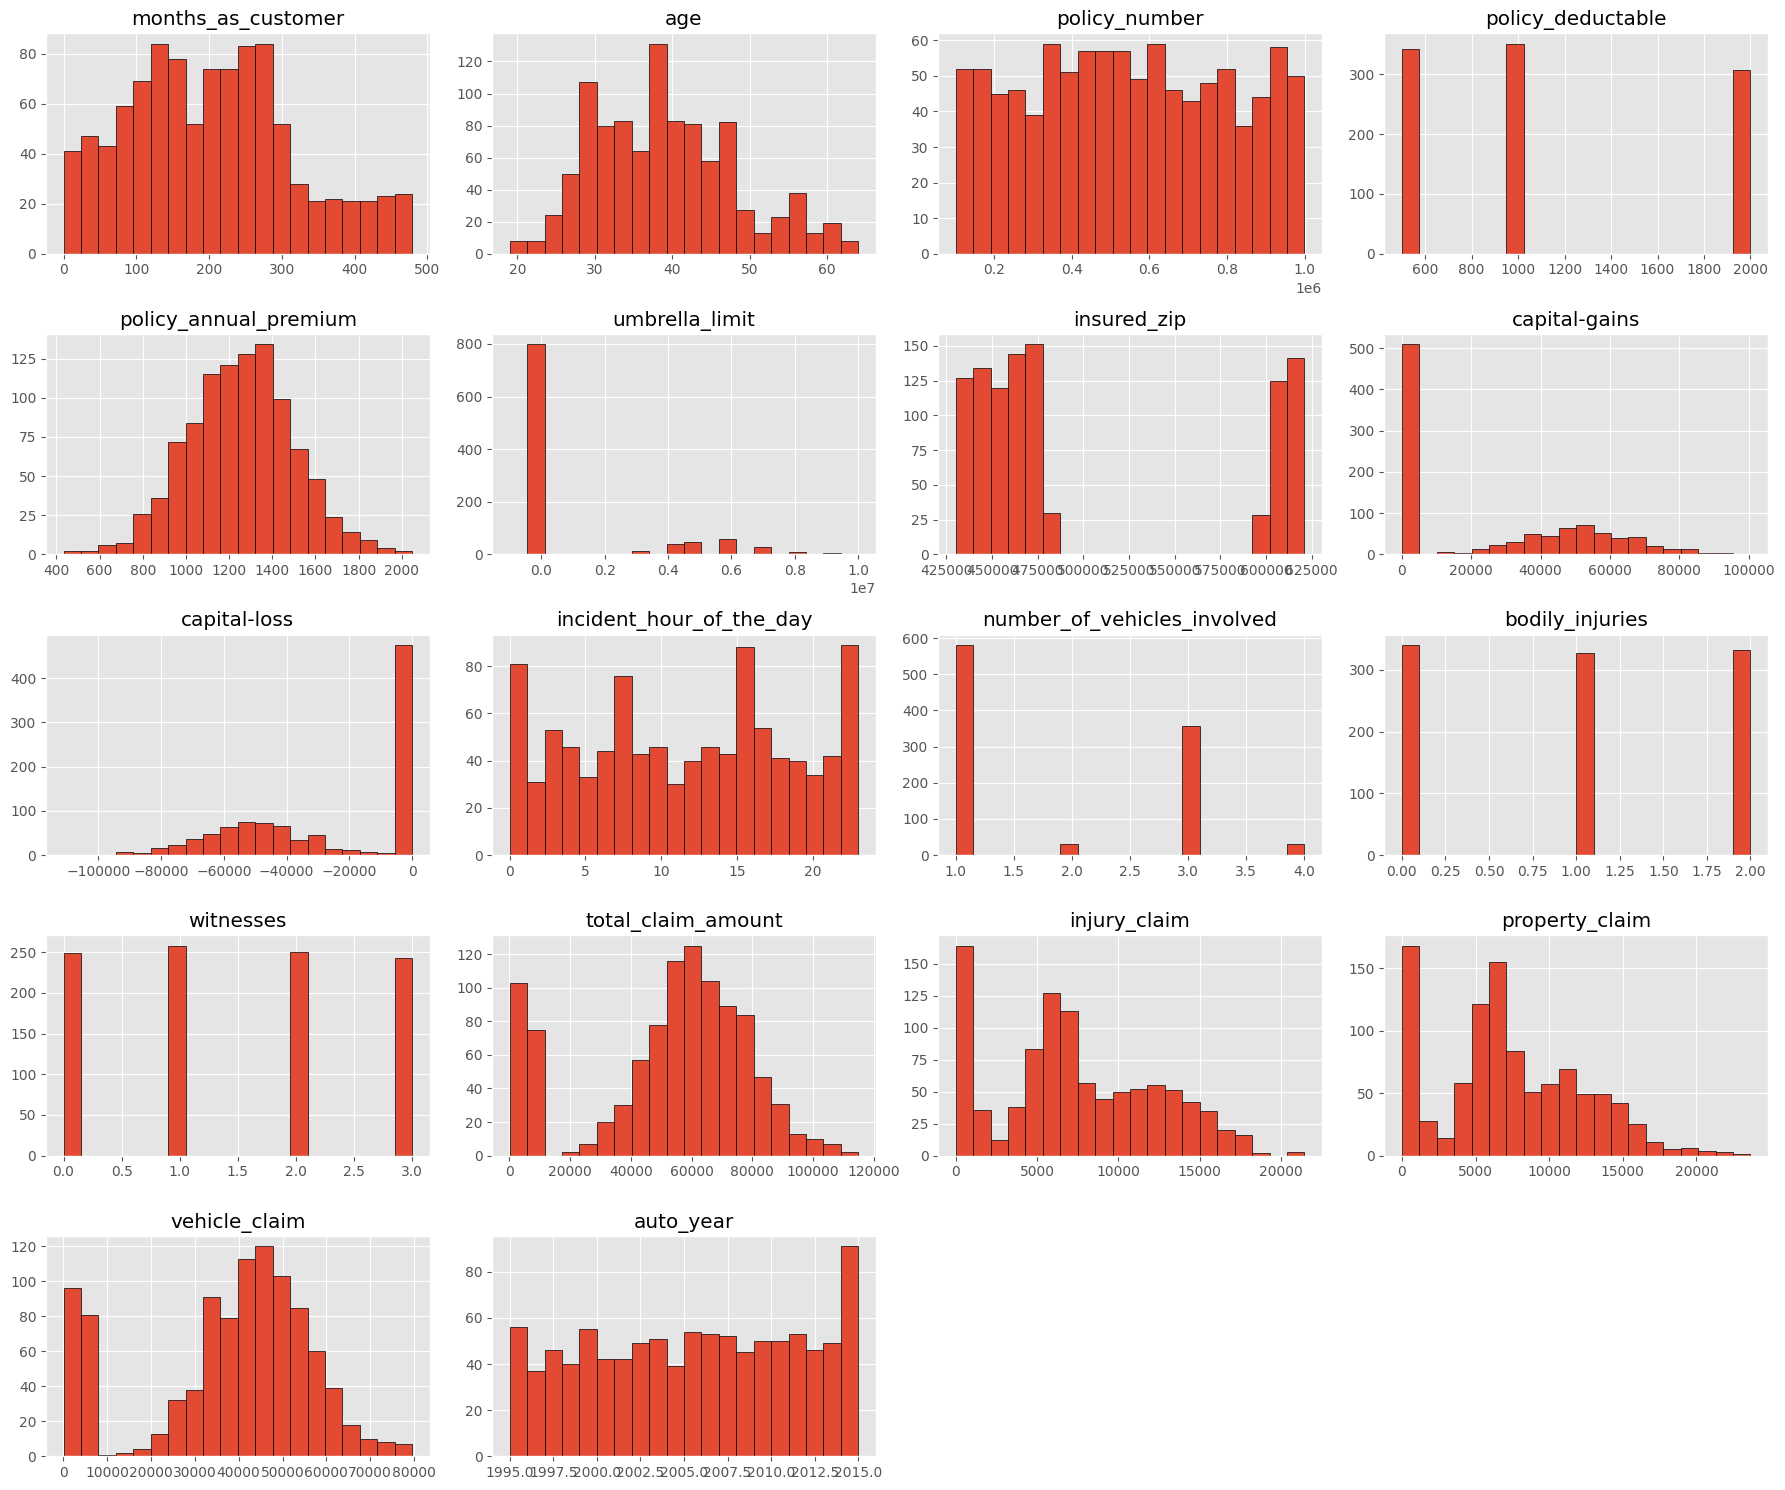

In [10]:

import matplotlib.pyplot as plt

df[numerical_cols].hist(
    figsize=(18, 15),
    bins=20,
    edgecolor="black"
)

plt.tight_layout()
plt.show()

# Observation


The numerical features exhibit diverse distributions. Some variables, such as `policy_annual_premium` and `total_claim_amount`, appear approximately bell-shaped, whereas others are highly skewed or contain a large proportion of zero values (e.g., `capital-gains`, `capital-loss`, and `umbrella_limit`). Several features represent discrete counts or categories encoded as numerical values (e.g., `number_of_vehicles_involved`, `bodily_injuries`, and `witnesses`). Potential outliers are also visible in several claim-related variables. These observations provide an initial understanding of the data and will be considered during later preprocessing and feature engineering stages.


#### Key Findings

- **`policy_number`** appears to be uniformly distributed across its range, suggesting that it functions as an identifier rather than a naturally distributed numerical variable.

- **`umbrella_limit`** is strongly right-skewed, with most observations concentrated at zero and relatively few high-limit policies.

- **`capital_gains`** is strongly right-skewed, with a large proportion of observations equal to zero and a small number of high values.

- **`capital_loss`** is strongly left-skewed, with many observations equal to zero and fewer observations with substantial losses.

- **`policy_deductable`**, **`number_of_vehicles_involved`**, **`bodily_injuries`**, and **`witnesses`** are discrete numerical variables with only a limited number of possible values.

- **`insured_zip`** exhibits multiple clusters rather than a continuous distribution, reflecting the presence of distinct geographic regions.

- **`auto_year`** spans from 1995 to 2015, with a noticeable concentration of newer vehicles, particularly model year 2015.

- **`total_claim_amount`** is approximately bell-shaped, while its components (`injury_claim`, `property_claim`, and `vehicle_claim`) show varying degrees of positive skewness, indicating that smaller claims are more common than very large claims.

# 3.5 Missing Values Analysis
The dataset was first examined for true missing values (`NaN`) to identify variables containing incomplete observations.

## 3.5.1 True Missing Values
The dataset was first examined for true missing values (`NaN`) to identify variables containing incomplete observations.

In [11]:
missing = (
    df.isnull()
      .sum()
      .loc[lambda x: x > 0]
      .sort_values(ascending=False)
      .reset_index()
)

missing.columns = ["Feature", "Missing Values"]
missing["Percentage"] = (
    missing["Missing Values"] / len(df) * 100
).round(1)

display(missing)

,Feature,Missing Values,Percentage
0,_c39,1000,100.0
1,authorities_contacted,91,9.1


## 3.5.2 Missing Value Markers
In addition to true missing values, the dataset was examined for placeholder values that represent missing information.

These markers are not detected by standard missing value functions because they are stored as ordinary string values. Identifying them provides a more complete assessment of data quality before the data cleaning stage.

In [12]:
missing_markers = (
    (df == "?")
    .sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
    .reset_index()
)

missing_markers.columns = ["Feature", "Question Mark Count"]

display(missing_markers)

,Feature,Question Mark Count
0,property_damage,360
1,police_report_available,343
2,collision_type,178


### Missing Values Observations

- Two variables contain true missing values (`NaN`): `_c39` and `authorities_contacted`.
- The `_c39` column consists entirely of missing values (100%), whereas `authorities_contacted` contains a relatively small proportion of missing observations (9.1%).
- Additional inspection identified the use of `"?"` as a missing value marker in three categorical variables: `property_damage`, `police_report_available`, and `collision_type`.
- These placeholders represent missing information but are stored as ordinary string values rather than true `NaN` values. Consequently, they are not identified by `isnull()` and will be converted to `NaN` during the data cleaning stage.

### 3.6 Duplicate Analysis

Duplicate records can introduce bias into exploratory analyses and machine learning models by overrepresenting certain observations. Therefore, the dataset was examined for duplicate rows before any data cleaning or preprocessing steps.

In [13]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


### 3.6.1 Policy Number Variable Duplicate Analysis

In addition to checking for duplicate rows, the uniqueness of the `policy_number` variable was examined because it appears to uniquely identify each insurance claim.  


### Observations

- No duplicate rows were found in the dataset.
- The absence of duplicate records suggests that no observations need to be removed at this stage.
- Potential identifier variables will be evaluated separately during the data cleaning and feature selection stages, as this is distinct from duplicate row detection.

### 3.7 Cardinality Analysis

The cardinality of categorical variables was examined to understand the number of unique categories within each feature.

Variables with a large number of unique values may require special consideration during preprocessing or feature engineering. At this stage, the analysis is descriptive only, and no variables are removed based on cardinality.

In [14]:
categorical_cols = df.select_dtypes(include="object").columns

cardinality = (
    df[categorical_cols]
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

cardinality.columns = ["Feature", "Unique Values"]

def classify_cardinality(x):
    if x <= 10:
        return "Low"
    elif x <= 30:
        return "Medium"
    else:
        return "High"

cardinality["Cardinality"] = cardinality["Unique Values"].apply(classify_cardinality)

display(cardinality)

,Feature,Unique Values,Cardinality
0,incident_location,1000,High
1,policy_bind_date,951,High
2,incident_date,60,High
3,auto_model,39,High
4,insured_hobbies,20,Medium
5,auto_make,14,Medium
6,insured_occupation,14,Medium
7,insured_education_level,7,Low
8,incident_city,7,Low
9,incident_state,7,Low


### Observations

- The categorical variables exhibit a wide range of cardinality levels, from binary variables to features with a unique value for nearly every observation.
- `incident_location` and `policy_bind_date` have exceptionally high cardinality, while `incident_date` and `auto_model` also contain a relatively large number of distinct values.
- Most remaining categorical variables have low to medium cardinality, making them suitable for standard categorical encoding techniques.
- High-cardinality variables are documented during the exploratory analysis only. Their suitability for modeling will be evaluated later during the data cleaning and feature selection stages.

# 3.8 Feature Relationships


In [15]:
df.columns.tolist()

['months_as_customer',
 'age',
 'policy_number',
 'policy_bind_date',
 'policy_state',
 'policy_csl',
 'policy_deductable',
 'policy_annual_premium',
 'umbrella_limit',
 'insured_zip',
 'insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'insured_relationship',
 'capital-gains',
 'capital-loss',
 'incident_date',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_city',
 'incident_location',
 'incident_hour_of_the_day',
 'number_of_vehicles_involved',
 'property_damage',
 'bodily_injuries',
 'witnesses',
 'police_report_available',
 'total_claim_amount',
 'injury_claim',
 'property_claim',
 'vehicle_claim',
 'auto_make',
 'auto_model',
 'auto_year',
 'fraud_reported',
 '_c39']

# 3.8.1 capital_gains vs capital_loss

In [16]:
# Check whether capital gains and capital losses occur together

pd.crosstab(
    df["capital-gains"] > 0,
    df["capital-loss"] > 0,
    margins=True
)

capital-loss,False,All
capital-gains,,
False,508,508
True,492,492
All,1000,1000


In [17]:
# Number of records where both are greater than zero

both_nonzero = (
    (df["capital-gains"] > 0) &
    (df["capital-loss"] > 0)
).sum()

print(f"Records with both capital gains and capital losses: {both_nonzero}")

Records with both capital gains and capital losses: 0


# Observation: 

No record contains both positive capital-gains and positive capital-loss values. All observations have a capital-loss value of zero, while approximately half of the records have positive capital-gains values. This pattern should be considered during feature engineering.

# 3.9 Correlation Analysis (Numerical Features)
Correlation analysis was performed to identify linear relationships among numerical features. This analysis helps detect potential multicollinearity and provides insight into feature relationships before model development.

In [18]:
# Select numerical features
numerical_features = df.select_dtypes(include="number")

# Correlation matrix
corr_matrix = numerical_features.corr(numeric_only=True)

corr_matrix.round(2)

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
months_as_customer,1.00,0.92,0.06,0.03,0.01,0.02,0.02,0.01,0.02,0.07,0.01,-0.01,0.06,0.06,0.07,0.03,0.06,-0.00,NaN
age,0.92,1.00,0.06,0.03,0.01,0.02,0.03,-0.01,0.01,0.09,0.02,-0.02,0.05,0.07,0.08,0.06,0.06,0.00,NaN
policy_number,0.06,0.06,1.00,-0.01,0.02,0.01,0.01,0.01,-0.01,0.00,0.01,-0.00,-0.01,-0.02,-0.01,-0.01,-0.02,-0.00,NaN
policy_deductable,0.03,0.03,-0.01,1.00,-0.00,0.01,0.00,0.04,-0.02,0.06,0.05,-0.02,0.07,0.02,0.04,0.06,0.01,0.03,NaN
policy_annual_premium,0.01,0.01,0.02,-0.00,1.00,-0.01,0.03,-0.01,0.02,-0.00,-0.05,0.03,0.00,0.01,-0.02,-0.01,0.02,-0.05,NaN
umbrella_limit,0.02,0.02,0.01,0.01,-0.01,1.00,0.02,-0.05,-0.02,-0.02,-0.02,0.02,-0.01,-0.04,-0.05,-0.02,-0.04,0.01,NaN
insured_zip,0.02,0.03,0.01,0.00,0.03,0.02,1.00,0.01,0.05,0.01,0.03,0.03,0.02,-0.03,-0.02,-0.01,-0.04,-0.03,NaN
capital-gains,0.01,-0.01,0.01,0.04,-0.01,-0.05,0.01,1.00,-0.05,-0.02,0.06,0.06,-0.02,0.02,0.03,-0.00,0.02,0.03,NaN
capital-loss,0.02,0.01,-0.01,-0.02,0.02,-0.02,0.05,-0.05,1.00,-0.03,-0.01,-0.02,-0.04,-0.04,-0.05,-0.02,-0.03,-0.06,NaN
incident_hour_of_the_day,0.07,0.09,0.00,0.06,-0.00,-0.02,0.01,-0.02,-0.03,1.00,0.12,-0.03,0.01,0.22,0.17,0.18,0.22,0.02,NaN


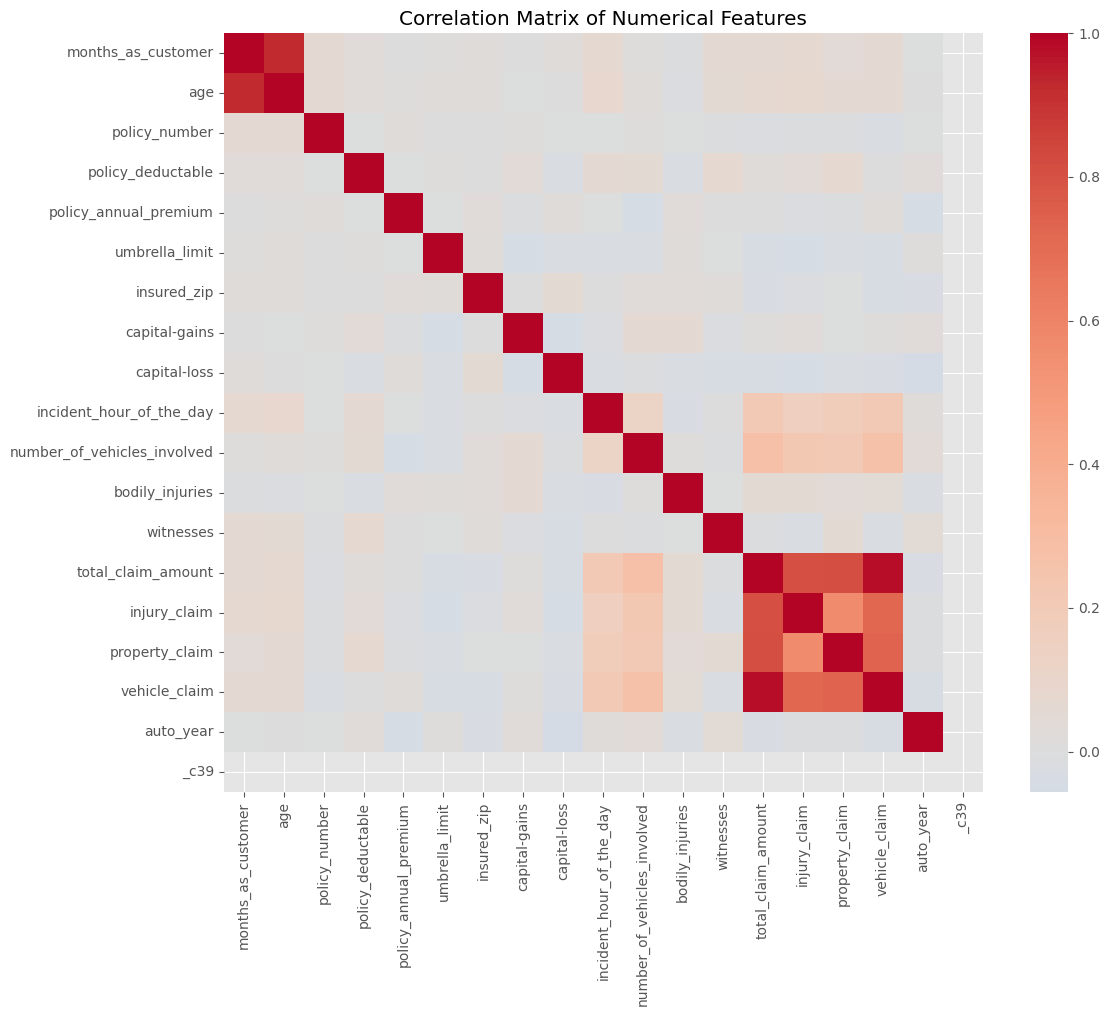

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [20]:
# Display highly correlated feature pairs (|r| >= 0.7)

corr_pairs = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

high_corr = corr_pairs[
    corr_pairs["Correlation"].abs() >= 0.7
].sort_values("Correlation", ascending=False)

display(high_corr)

,Feature 1,Feature 2,Correlation
145,total_claim_amount,vehicle_claim,0.982773
0,months_as_customer,age,0.922098
144,total_claim_amount,property_claim,0.810686
143,total_claim_amount,injury_claim,0.805025
150,property_claim,vehicle_claim,0.732090
148,injury_claim,vehicle_claim,0.722878


In [21]:
(
    df["injury_claim"]
    + df["property_claim"]
    + df["vehicle_claim"]
    == df["total_claim_amount"]
).all()

np.True_

# Observation


1. total_claim_amount ile vehicle_claim (r = 0.98)
total_claim_amount ↔ vehicle_claim      0.98
total_claim_amount ↔ property_claim     0.81
total_claim_amount ↔ injury_claim       0.81

2. injury/property/vehicle claim
vehicle_claim ↔ property_claim 0.73

vehicle_claim ↔ injury_claim 0.72

Most numerical features exhibit weak linear correlations. Strong correlations are observed between months_as_customer and age (r = 0.92), as well as among claim-related variables, particularly total_claim_amount and vehicle_claim (r = 0.98). These relationships suggest potential redundancy and will be examined further during feature selection after the train-test split.

In [22]:
(
    df["injury_claim"]
    + df["property_claim"]
    + df["vehicle_claim"]
    == df["total_claim_amount"]
).value_counts()

True    1000
Name: count, dtype: int64

# Observation: 

The correlation analysis identified strong relationships among claim-related variables. Further inspection confirmed that total_claim_amount is exactly equal to the sum of injury_claim, property_claim, and vehicle_claim for all observations. This deterministic relationship will be considered during feature selection to avoid redundant information.

### 3.10 Categorical Feature Class Distribution

The frequency distribution of each categorical feature is presented below to examine class balance and identify high-cardinality variables.

In [23]:
categorical_cols = df.select_dtypes(include="object").columns

print(f"Number of categorical features: {len(categorical_cols)}")
categorical_cols

Number of categorical features: 21


Index(['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'incident_date', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'incident_state', 'incident_city', 'incident_location',
       'property_damage', 'police_report_available', 'auto_make', 'auto_model',
       'fraud_reported'],
      dtype='object')

In [24]:
for col in categorical_cols:

    print("=" * 80)
    print(f"Feature: {col}")
    print(f"Unique categories: {df[col].nunique(dropna=False)}")

    distribution = (
        df[col]
        .value_counts(dropna=False)
        .rename_axis("Category")
        .reset_index(name="Count")
    )

    distribution["Percentage (%)"] = (
        distribution["Count"] / len(df) * 100
    ).round(2)

    display(distribution)

Feature: policy_bind_date
Unique categories: 951


,Category,Count,Percentage (%)
0,2006-01-01,3,0.3
1,1992-04-28,3,0.3
2,1992-08-05,3,0.3
3,1991-12-14,2,0.2
4,2004-08-09,2,0.2
...,...,...,...
946,2014-06-03,1,0.1
947,1998-12-12,1,0.1
948,1999-02-18,1,0.1
949,1997-10-30,1,0.1


Feature: policy_state
Unique categories: 3


,Category,Count,Percentage (%)
0,OH,352,35.2
1,IL,338,33.8
2,IN,310,31.0


Feature: policy_csl
Unique categories: 3


...

,Category,Count,Percentage (%)
0,Saab,80,8.0
1,Dodge,80,8.0
2,Suburu,80,8.0
3,Nissan,78,7.8
4,Chevrolet,76,7.6
5,Ford,72,7.2
6,BMW,72,7.2
7,Toyota,70,7.0
8,Audi,69,6.9
9,Accura,68,6.8


Feature: auto_model
Unique categories: 39


,Category,Count,Percentage (%)
0,RAM,43,4.3
1,Wrangler,42,4.2
2,A3,37,3.7
3,Neon,37,3.7
4,MDX,36,3.6
5,Jetta,35,3.5
6,Passat,33,3.3
7,A5,32,3.2
8,Legacy,32,3.2
9,Pathfinder,31,3.1


Feature: fraud_reported
Unique categories: 2


,Category,Count,Percentage (%)
0,N,753,75.3
1,Y,247,24.7


In [25]:
import numpy as np
import pandas as pd

summary = pd.DataFrame({
    "Feature": categorical_cols,
    "Unique Categories": [
        df[col].nunique(dropna=False)
        for col in categorical_cols
    ],
    "Missing Values": [
        df[col].isna().sum()
        for col in categorical_cols
    ],
    "Most Frequent Category": [
        df[col].mode(dropna=False)[0]
        for col in categorical_cols
    ],
    "Most Frequent Category (%)": [
        round(
            df[col]
            .value_counts(dropna=False, normalize=True)
            .iloc[0] * 100,
            2
        )
        for col in categorical_cols
    ]
})

summary["High Cardinality (≥20)"] = np.where(
    summary["Unique Categories"] >= 20,
    "Yes",
    "No"
)

summary = summary[
    [
        "Feature",
        "Unique Categories",
        "High Cardinality (≥20)",
        "Missing Values",
        "Most Frequent Category",
        "Most Frequent Category (%)"
    ]
]

summary

,Feature,Unique Categories,High Cardinality (≥20),Missing Values,Most Frequent Category,Most Frequent Category (%)
0,policy_bind_date,951,Yes,0,1992-04-28,0.3
1,policy_state,3,No,0,OH,35.2
2,policy_csl,3,No,0,250/500,35.1
3,insured_sex,2,No,0,FEMALE,53.7
4,insured_education_level,7,No,0,JD,16.1
5,insured_occupation,14,No,0,machine-op-inspct,9.3
6,insured_hobbies,20,Yes,0,reading,6.4
7,insured_relationship,6,No,0,own-child,18.3
8,incident_date,60,Yes,0,2015-02-02,2.8
9,incident_type,4,No,0,Multi-vehicle Collision,41.9


**Observation

The categorical features exhibit varying levels of cardinality. Most variables contain only a small number of categories, whereas `policy_bind_date`, `incident_date`, `incident_location`, and `auto_model` have high cardinality. `insured_hobbies` also contains a relatively large number of distinct categories.

Most categorical variables do not contain missing values. However, `authorities_contacted` contains 91 missing observations (9.1%). In addition, `property_damage`, `police_report_available`, and `collision_type` include `"?"` values, which will be investigated during the data cleaning stage.

The target variable (`fraud_reported`) is imbalanced, with approximately 75% non-fraud cases and 25% fraud cases.

# 3.10.1 Summary of Categorical Features

In [26]:
summary = pd.DataFrame({
    "Feature": categorical_cols,
    "Unique Categories": [df[col].nunique(dropna=False) for col in categorical_cols],
    "Missing Values": [df[col].isna().sum() for col in categorical_cols],
    "Most Frequent Category": [df[col].mode(dropna=False)[0] for col in categorical_cols],
    "Frequency (%)": [
        round(df[col].value_counts(dropna=False, normalize=True).iloc[0] * 100, 2)
        for col in categorical_cols
    ]
})

summary

,Feature,Unique Categories,Missing Values,Most Frequent Category,Frequency (%)
0,policy_bind_date,951,0,1992-04-28,0.3
1,policy_state,3,0,OH,35.2
2,policy_csl,3,0,250/500,35.1
3,insured_sex,2,0,FEMALE,53.7
4,insured_education_level,7,0,JD,16.1
5,insured_occupation,14,0,machine-op-inspct,9.3
6,insured_hobbies,20,0,reading,6.4
7,insured_relationship,6,0,own-child,18.3
8,incident_date,60,0,2015-02-02,2.8
9,incident_type,4,0,Multi-vehicle Collision,41.9


**Observation**

The summary confirms that categorical features vary considerably in their cardinality. Several variables have only a few categories (e.g., `insured_sex`, `policy_state`, `incident_type`), whereas others such as `policy_bind_date`, `incident_date`, and `incident_location` contain many unique values. Most categorical variables contain no missing values, except `authorities_contacted`, which has 91 missing observations. Additionally, the target variable (`fraud_reported`) is imbalanced, with approximately 75% of observations belonging to the non-fraud class.

### Key Findings

- **`policy_bind_date`** contains 951 unique categories, indicating very high cardinality. This feature may require additional consideration during preprocessing.

- **`incident_location`** contains 1000 unique categories, with nearly every observation having a distinct value. This suggests extremely high cardinality.

- **`incident_date`** (60 unique values) and **`auto_model`** (39 unique values) also exhibit relatively high cardinality compared with the remaining categorical features.

- **`authorities_contacted`** is the only categorical feature containing true missing values (91 observations, 9.1%).

- **`property_damage`** and **`police_report_available`** contain `"?"` entries, while `collision_type` should also be reviewed because uncommon categories or placeholder values may require verification during data cleaning.

- The target variable **`fraud_reported`** is moderately imbalanced, with approximately 75% of observations labeled as non-fraud and 25% as fraud.

### 3.11 Target Variable Distribution

This section examines the distribution of the target variable (`fraud_reported`) to assess class balance before model development. Understanding the target distribution is important because class imbalance can influence model training and evaluation.

In [27]:
target_distribution = (
    df["fraud_reported"]
    .value_counts()
    .rename_axis("Fraud Reported")
    .reset_index(name="Count")
)

target_distribution["Percentage (%)"] = (
    target_distribution["Count"] / len(df) * 100
).round(2)

target_distribution

,Fraud Reported,Count,Percentage (%)
0,N,753,75.3
1,Y,247,24.7


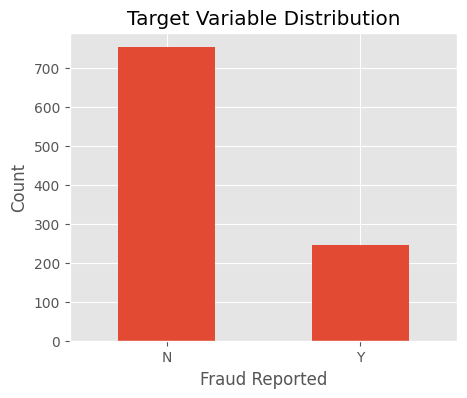

In [28]:
plt.figure(figsize=(5, 4))

ax = df["fraud_reported"].value_counts().plot(
    kind="bar",
    rot=0
)

ax.set_title("Target Variable Distribution")
ax.set_xlabel("Fraud Reported")
ax.set_ylabel("Count")

plt.show()

**Observation**

The target variable (`fraud_reported`) exhibits a moderate class imbalance. Approximately **75.3%** of the observations correspond to non-fraudulent claims (`N`), while **24.7%** represent fraudulent claims (`Y`). Although the classes are not perfectly balanced, both are sufficiently represented for supervised learning. Nevertheless, this imbalance should be considered when selecting evaluation metrics and training classification models.

### 3.12 EDA Summary

The exploratory data analysis provided the following key observations:

- The dataset contains **1,000 insurance claims** with a mix of numerical and categorical features.
- One column (`_c39`) contains only missing values, while `authorities_contacted` includes genuine missing values. Several categorical variables (`collision_type`, `property_damage`, and `police_report_available`) contain `"?"` values that require further investigation during data cleaning.
- No duplicate records were identified.
- Several variables exhibit **high cardinality**, including `policy_bind_date`, `incident_location`, `incident_date`, and `auto_model`.
- Numerical features display diverse distributions. Variables such as `capital_gains` and `umbrella_limit` are strongly right-skewed, whereas `capital_loss` is strongly left-skewed. Several variables are discrete with only a small number of possible values.
- The three claim components (`injury_claim`, `property_claim`, and `vehicle_claim`) sum exactly to `total_claim_amount`, indicating potential redundancy that will be evaluated in later stages.
- The target variable (`fraud_reported`) exhibits a **moderate class imbalance**, with approximately **75%** non-fraudulent and **25%** fraudulent claims.
- No feature selection decisions are made at this stage. The observations from the EDA will guide the subsequent data cleaning, feature engineering, and modeling steps.

# 4. Initial Data Cleaning

This section performs the initial data cleaning steps before splitting the dataset into training and testing sets. Only dataset-level cleaning operations are performed at this stage, including removing identifier columns, handling obvious missing values, standardizing column names, and correcting data types.

No feature selection or target-based decisions are made during this stage in order to avoid introducing data leakage.

### 4.1 Rename Columns

Column names are standardized by replacing hyphens (`-`) with underscores (`_`) to improve consistency and simplify subsequent analysis.

In [29]:
df.columns = df.columns.str.replace("-", "_", regex=False)

pd.Series(df.columns, name="Column Name")

0              months_as_customer
1                             age
2                   policy_number
3                policy_bind_date
4                    policy_state
5                      policy_csl
6               policy_deductable
7           policy_annual_premium
8                  umbrella_limit
9                     insured_zip
10                    insured_sex
11        insured_education_level
12             insured_occupation
13                insured_hobbies
14           insured_relationship
15                  capital_gains
16                   capital_loss
17                  incident_date
18                  incident_type
19                 collision_type
20              incident_severity
21          authorities_contacted
22                 incident_state
23                  incident_city
24              incident_location
25       incident_hour_of_the_day
26    number_of_vehicles_involved
27                property_damage
28                bodily_injuries
29            

In [30]:
df.columns = df.columns.str.replace("-", "_", regex=False)

print("Column names have been standardized.")

Column names have been standardized.


# Hyphens in column names were successfully replaced with underscores to improve readability and ensure consistent naming throughout the analysis.

### 4.2 Identify Missing Value Markers

Before handling missing values, the dataset is scanned for both standard missing values (`NaN`) and commonly used placeholder values such as `"?"`, `"NA"`, `"NULL"`, and similar markers.

In [31]:
missing_markers = [
    "?",
    "NA",
    "N/A",
    "na",
    "n/a",
    "NaN",
    "nan",
    "NULL",
    "null",
    "None",
    "none",
    "-",
    "--"
]

results = []

for col in df.columns:

    counts = {}

    for marker in missing_markers:
        counts[marker] = (df[col] == marker).sum()

    counts["real_NaN"] = df[col].isna().sum()
    counts["total_missing_like_values"] = sum(counts.values())

    if counts["total_missing_like_values"] > 0:
        counts["Column"] = col
        results.append(counts)

missing_summary = (
    pd.DataFrame(results)
    .set_index("Column")
)

missing_summary

,?,NA,N/A,na,n/a,NaN,nan,NULL,null,None,none,-,--,real_NaN,total_missing_like_values
Column,,,,,,,,,,,,,,,
collision_type,178,0,0,0,0,0,0,0,0,0,0,0,0,0,178
authorities_contacted,0,0,0,0,0,0,0,0,0,0,0,0,0,91,91
property_damage,360,0,0,0,0,0,0,0,0,0,0,0,0,0,360
police_report_available,343,0,0,0,0,0,0,0,0,0,0,0,0,0,343
_c39,0,0,0,0,0,0,0,0,0,0,0,0,0,1000,1000


# Observation**

The scan identified one column (`_c39`) containing only missing values. In addition, `authorities_contacted` contains genuine missing values (`NaN`), while `collision_type`, `property_damage`, and `police_report_available` use `"?"` as placeholder values rather than true missing values. These placeholder values will be handled in the subsequent cleaning steps.

### 4.3 Remove Columns with Excessive Missing Values

Columns containing an excessive proportion of missing values provide little or no useful information for analysis. Such columns are removed prior to model development.

In [32]:
# Remove columns with all missing values
df.drop(columns=["_c39"], inplace=True)

print(df.shape)

(1000, 39)


# Observation**

The `_c39` column was removed because it contained only missing values (100% missingness) and therefore did not contribute any useful information for subsequent analysis.

### 4.4 Remove Duplicate Records

Duplicate records can introduce bias during model training by overrepresenting certain observations. Therefore, the dataset is checked for duplicate rows before proceeding with further preprocessing.

In [33]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [34]:
df.drop_duplicates(inplace=True)

print(df.shape)

(1000, 39)


# Observation**

No duplicate records were identified in the dataset. Therefore, no observations were removed during this step.

### 4.5 Remove Identifier Columns

Identifier variables uniquely identify observations but do not provide predictive information. Before removing such variables, their uniqueness is verified.

In [35]:
# Check index
print(df.index)

# Check whether any column looks like an identifier
for col in df.columns:
    unique_ratio = df[col].nunique() / len(df)
    if unique_ratio > 0.95:
        print(f"{col}: {df[col].nunique()} unique values ({unique_ratio:.1%})")

RangeIndex(start=0, stop=1000, step=1)
policy_number: 1000 unique values (100.0%)
policy_bind_date: 951 unique values (95.1%)
policy_annual_premium: 991 unique values (99.1%)
insured_zip: 995 unique values (99.5%)
incident_location: 1000 unique values (100.0%)


In [36]:
identifier_summary = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Unique Ratio": (df.nunique() / len(df)).round(3)
}).sort_values("Unique Ratio", ascending=False)

identifier_summary.head(10)

,Unique Values,Unique Ratio
policy_number,1000,1.000
incident_location,1000,1.000
insured_zip,995,0.995
policy_annual_premium,991,0.991
policy_bind_date,951,0.951
total_claim_amount,763,0.763
vehicle_claim,726,0.726
injury_claim,638,0.638
property_claim,626,0.626
months_as_customer,391,0.391


In [37]:
# Verify uniqueness
print(f"Unique policy numbers: {df['policy_number'].nunique()}")
print(f"Total records: {len(df)}")

Unique policy numbers: 1000
Total records: 1000


In [38]:
df.drop(columns=["policy_number"], inplace=True)

print(df.shape)

(1000, 38)


# Observation**

Several variables exhibit high cardinality, including incident_location, insured_zip, policy_bind_date, and policy_annual_premium. However, high cardinality alone does not imply that a variable is an identifier. Only policy_number uniquely identifies each policy and therefore was classified as an identifier and removed. The remaining variables contain meaningful information and will be retained for subsequent analysis.

### 4.6 Convert Data Types

Date columns are converted from string format to the appropriate `datetime` data type to facilitate subsequent temporal feature engineering.

In [39]:
date_columns = ["policy_bind_date", "incident_date"]

df[date_columns] = df[date_columns].apply(
    pd.to_datetime,
    errors="coerce"
)

df[date_columns].dtypes

policy_bind_date    datetime64[ns]
incident_date       datetime64[ns]
dtype: object

**Observation**

Both date columns were successfully converted to the `datetime` data type. No parsing errors were observed, allowing these variables to be used later for feature engineering.

### 4.7 Standardize Missing Value Markers

Several categorical variables use `"?"` to represent missing information instead of standard missing values. These placeholders are replaced with `NaN` to ensure consistent handling of missing data throughout the analysis.

In [40]:
columns_with_placeholders = [
    "collision_type",
    "property_damage",
    "police_report_available"
]

df[columns_with_placeholders] = df[columns_with_placeholders].replace("?", np.nan)

df[columns_with_placeholders].isna().sum()

collision_type             178
property_damage            360
police_report_available    343
dtype: int64

# Observation**

Placeholder values (`"?"`) were successfully converted to standard missing values (`NaN`) in the affected categorical variables. This ensures that missing data will be handled consistently during preprocessing and model development.

### 4.8 Remove Redundant Features

Before model development, features that do not provide additional information are identified and removed. Redundant variables can increase model complexity without improving predictive performance.

The relationship between the total claim amount and its individual claim components is verified before deciding whether the variable should be retained.

In [41]:
(
    df["injury_claim"]
    + df["property_claim"]
    + df["vehicle_claim"]
    == df["total_claim_amount"]
).all()

np.True_

In [42]:
df.drop(columns=["total_claim_amount"], inplace=True)

print(df.shape)

(1000, 37)


**Observation**

The `total_claim_amount` variable was verified to be the exact sum of `injury_claim`, `property_claim`, and `vehicle_claim`. Since it does not provide additional information beyond these component variables, it was removed to eliminate redundancy while retaining the underlying claim details.

### Data Cleaning Summary

The initial data cleaning stage included the following steps:

- Standardized column names by replacing hyphens with underscores.
- Identified both genuine and placeholder missing values.
- Removed the `_c39` column because it contained only missing values.
- Confirmed that the dataset contained no duplicate records.
- Removed the `policy_number` identifier column.
- Converted date variables to the `datetime` data type.
- Standardized placeholder values (`"?"`) by replacing them with `NaN`.
- Removed the redundant `total_claim_amount` variable after confirming that it was fully determined by its three component claim variables.
- The authorities_contacted variable contains 91 genuine missing (NaN) values. These values are intentionally retained at this stage and will be handled during the preprocessing phase after the train-test split to avoid data leakage.

At this stage, only dataset-level cleaning operations have been performed. Missing value imputation, feature selection, feature engineering, encoding, and scaling will be carried out after the train-test split to prevent data leakage.

# 5. Train-Test Split

To ensure an unbiased evaluation of model performance, the dataset is split into training and testing sets before any target-based feature selection or preprocessing.

All subsequent preprocessing steps, including missing value imputation, feature selection, encoding, and scaling, will be performed using only the training data to prevent data leakage.

5.1 Define Features and Target

In [43]:
X = df.drop(columns=["fraud_reported"])
y = df["fraud_reported"]

print(f"Features: {X.shape}")
print(f"Target: {y.shape}")

Features: (1000, 36)
Target: (1000,)


### 5.2 Split the Dataset

The dataset is divided into training and testing subsets using stratified sampling to preserve the class distribution of the target variable in both sets.

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Training set: (800, 36)
Test set: (200, 36)


5.3 Verify Target Distribution

In [45]:
target_distribution = pd.DataFrame({
    "Full Dataset": y.value_counts(normalize=True),
    "Training Set": y_train.value_counts(normalize=True),
    "Test Set": y_test.value_counts(normalize=True)
}).round(3)

target_distribution

,Full Dataset,Training Set,Test Set
fraud_reported,,,
N,0.753,0.752,0.755
Y,0.247,0.248,0.245


# Observation**

The dataset was successfully divided into training (80%) and testing (20%) subsets using stratified sampling. The class distribution of the target variable remained nearly identical across the full dataset, training set, and test set, confirming that the split preserved the original class proportions.

# 6. Feature Selection (Training Set Only) & Redundancy Analysis

After completing the initial data exploration, data cleaning, and train-test split, the next step is to identify redundant features using only the training dataset.

The objective of this stage is not to evaluate the relationship between the predictors and the target variable. Instead, it focuses on identifying variables that provide overlapping or duplicate information. Removing redundant features helps simplify the model, reduce multicollinearity, and improve model interpretability while preventing data leakage.

The redundancy analysis consists of three complementary approaches:


- **Correlation Analysis** to identify highly correlated numerical variables.
- **Variance Inflation Factor (VIF)** to detect multicollinearity among numerical predictors.
- **Cramer's V Analysis** to measure associations between categorical variables.

Based on these analyses, redundant variables will be identified and considered for removal before proceeding to the target-based feature selection stage.

# 6.1 Feature Type Identification

In [46]:
# Identify numerical and categorical predictors

numerical_features = X_train.select_dtypes(include=["number"]).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

datetime_features = X_train.select_dtypes(
    include="datetime"
).columns.tolist()

print(f"Numerical features : {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Datetime features   : {len(datetime_features)}")

Numerical features : 16
Categorical features: 18
Datetime features   : 2


# Observation**

The training dataset contains 16 numerical features, 18 categorical features, and 2 datetime features. Separating variables by data type enables the application of appropriate redundancy analysis techniques. Correlation analysis and VIF will be used to assess redundancy among numerical variables, while Cramer's V will evaluate associations between categorical variables. Datetime variables will be handled separately during the feature engineering stage.

# 6.2 Correlation Analysis
The first step of the redundancy analysis is to evaluate the relationships among the numerical predictor variables using the Pearson correlation coefficient.

Highly correlated features may provide overlapping information, leading to unnecessary redundancy in the feature set. Identifying these relationships helps simplify the model while preserving its predictive capability.

Since the Pearson correlation coefficient is applicable only to numerical variables, this analysis is performed exclusively on the numerical features identified in the previous section.

Feature pairs with an absolute correlation coefficient greater than 0.80 are considered candidates for redundancy and will be examined further.



In [47]:
# Compute the Pearson correlation matrix for numerical features

corr_matrix = X_train[numerical_features].corr(method="pearson")

corr_matrix.round(2)

,months_as_customer,age,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital_gains,capital_loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,injury_claim,property_claim,vehicle_claim,auto_year
months_as_customer,1.00,0.92,0.01,-0.02,0.03,0.01,0.00,0.01,0.10,0.03,0.01,0.03,0.06,0.01,0.05,0.02
age,0.92,1.00,0.01,-0.01,0.02,0.02,-0.02,-0.01,0.10,0.03,0.01,0.03,0.07,0.05,0.05,0.02
policy_deductable,0.01,0.01,1.00,0.01,0.03,-0.00,0.05,-0.04,0.09,0.07,-0.01,0.05,0.03,0.05,0.02,0.04
policy_annual_premium,-0.02,-0.01,0.01,1.00,-0.00,0.04,-0.03,0.02,-0.01,-0.06,0.01,-0.03,-0.02,-0.01,0.03,-0.07
umbrella_limit,0.03,0.02,0.03,-0.00,1.00,0.06,-0.03,-0.03,-0.06,-0.03,0.04,0.02,-0.05,-0.04,-0.05,0.02
insured_zip,0.01,0.02,-0.00,0.04,0.06,1.00,-0.03,0.05,-0.00,0.02,0.02,-0.01,-0.01,0.03,-0.02,-0.06
capital_gains,0.00,-0.02,0.05,-0.03,-0.03,-0.03,1.00,-0.07,-0.04,0.05,0.05,-0.03,0.02,-0.00,0.00,0.04
capital_loss,0.01,-0.01,-0.04,0.02,-0.03,0.05,-0.07,1.00,-0.01,0.00,-0.04,-0.03,-0.05,-0.02,-0.03,-0.05
incident_hour_of_the_day,0.10,0.10,0.09,-0.01,-0.06,-0.00,-0.04,-0.01,1.00,0.14,-0.02,0.01,0.17,0.19,0.23,0.03
number_of_vehicles_involved,0.03,0.03,0.07,-0.06,-0.03,0.02,0.05,0.00,0.14,1.00,0.00,-0.02,0.25,0.23,0.28,0.03


# Correlation Heatmap
To facilitate interpretation, the correlation matrix is visualized using a heatmap. This provides a clearer overview of the relationships among numerical features and helps identify highly correlated feature pairs that may require further investigation.

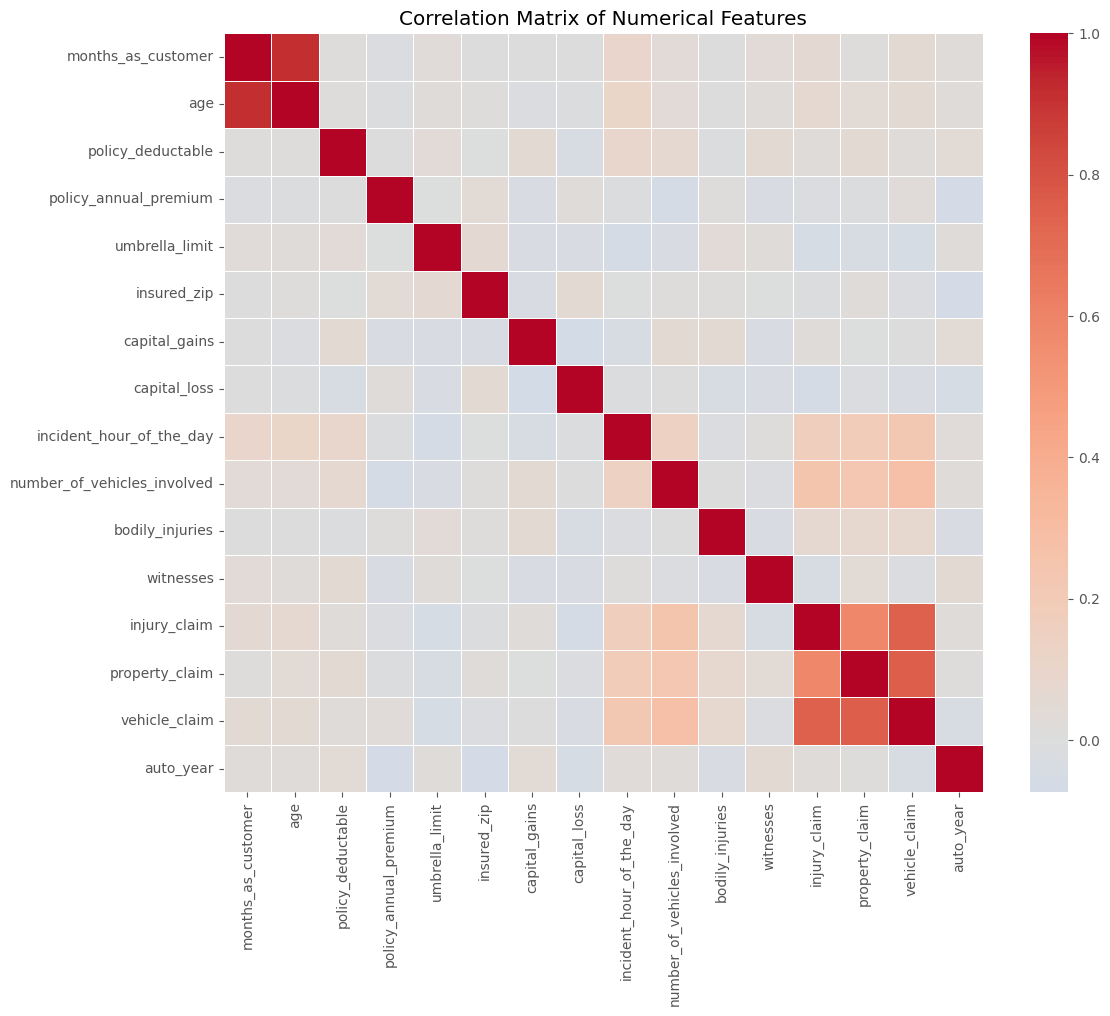

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the correlation heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot=False
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()


In [49]:
# Identify highly correlated feature pairs

threshold = 0.80

high_corr_pairs = (
    corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

high_corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]

high_corr_pairs = high_corr_pairs[
    high_corr_pairs["Correlation"].abs() > threshold
].sort_values(
    by="Correlation",
    key=lambda x: x.abs(),
    ascending=False
)

high_corr_pairs

,Feature_1,Feature_2,Correlation
0,months_as_customer,age,0.920221


# Interpretation

The Pearson correlation analysis identified only one pair of numerical variables with an absolute correlation coefficient exceeding the predefined threshold of 0.80:

months_as_customer and age (r = 0.92)

This strong positive correlation indicates that these two variables capture highly similar information and may therefore introduce redundancy into the feature set. All remaining numerical feature pairs exhibited correlations below the threshold, suggesting limited pairwise linear dependence among the other predictors.

Although the correlation results indicate that months_as_customer and age are potential candidates for redundancy, correlation analysis alone is not sufficient to determine whether one of the variables should be removed. The final decision will be supported by the Variance Inflation Factor (VIF) analysis, which evaluates multicollinearity within the complete set of numerical predictors.

# 6.3 Variance Inflation Factor (VIF) 
While correlation analysis evaluates relationships between pairs of numerical features, the Variance Inflation Factor (VIF) assesses the degree of multicollinearity among all numerical predictors simultaneously.

A high VIF value indicates that a feature can be largely explained by other predictors, suggesting potential redundancy. Identifying such variables helps reduce multicollinearity and improves the stability and interpretability of the model.

As a general guideline:

VIF < 5 indicates low multicollinearity.
5 ≤ VIF < 10 indicates moderate multicollinearity.
VIF ≥ 10 indicates severe multicollinearity.

In [50]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Calculate VIF for numerical features
vif_data = pd.DataFrame()

vif_data["Feature"] = numerical_features

vif_data["VIF"] = [
    variance_inflation_factor(
        X_train[numerical_features].values, i
    )
    for i in range(len(numerical_features))
]

vif_data = vif_data.sort_values("VIF", ascending=False)

vif_data


,Feature,VIF
15,auto_year,133.594651
1,age,128.839985
5,insured_zip,49.927380
3,policy_annual_premium,28.521436
0,months_as_customer,27.854305
14,vehicle_claim,16.808012
13,property_claim,7.616705
12,injury_claim,7.344057
9,number_of_vehicles_involved,4.723205
2,policy_deductable,4.515746


In [51]:
vif_before = vif_data.copy()

# Interpretation

Interpretation

The VIF analysis identified several numerical features with elevated levels of multicollinearity. The highest VIF values were observed for auto_year (133.59), age (128.84), insured_zip (49.93), policy_annual_premium (28.52), months_as_customer (27.85), and vehicle_claim (16.81), indicating substantial multicollinearity.

In addition, property_claim (7.62) and injury_claim (7.34) exhibited moderate levels of multicollinearity, suggesting that these variables also share information with other numerical predictors.

While the correlation analysis identified only one highly correlated feature pair (months_as_customer and age), the VIF analysis indicates that multicollinearity extends beyond pairwise relationships. The combined results of the correlation and VIF analyses will be used to identify redundant numerical features before proceeding to the next stage of feature selection.

# Investigating High VIF Values
To better understand the source of the elevated VIF values, the correlation matrix is examined only for the numerical features with the highest VIF scores. This focused analysis helps identify whether strong pairwise relationships contribute to the observed multicollinearity.

In [52]:
corr_matrix.loc[
    [
        "age",
        "months_as_customer",
        "policy_annual_premium",
        "vehicle_claim",
        "property_claim",
        "injury_claim"
    ],
    [
        "age",
        "months_as_customer",
        "policy_annual_premium",
        "vehicle_claim",
        "property_claim",
        "injury_claim"
    ]
]

,age,months_as_customer,policy_annual_premium,vehicle_claim,property_claim,injury_claim
age,1.000000,0.920221,-0.007152,0.054584,0.046239,0.072394
months_as_customer,0.920221,1.000000,-0.017571,0.047905,0.014631,0.060280
policy_annual_premium,-0.007152,-0.017571,1.000000,0.026880,-0.008347,-0.019921
vehicle_claim,0.054584,0.047905,0.026880,1.000000,0.748596,0.744147
property_claim,0.046239,0.014631,-0.008347,0.748596,1.000000,0.580632
injury_claim,0.072394,0.060280,-0.019921,0.744147,0.580632,1.000000


# Interpretation

The focused correlation analysis confirms that the strong multicollinearity between age and months_as_customer is consistent with their high VIF values.

In contrast, the remaining variables do not exceed the predefined correlation threshold of 0.80. This suggests that the elevated VIF values observed for some features, such as policy_annual_premium, are likely driven by their combined linear relationships with multiple predictors rather than by a single highly correlated feature.

Therefore, both the correlation analysis and the VIF analysis should be considered together when identifying redundant numerical features.

# 6.4 Feature Removal Decision

Based on the combined results of the Pearson correlation and VIF analyses, the feature age was removed from the dataset.

The variables age and months_as_customer exhibited a very strong correlation (r = 0.92), indicating that they contain highly overlapping information. This finding was further supported by the VIF analysis, where age showed a VIF value of 128.84 and months_as_customer a VIF value of 27.85, confirming severe multicollinearity.

Between the two variables, months_as_customer was retained because it directly represents the customer's relationship duration with the insurance company, providing more domain-specific information for the insurance context. Since age conveys largely overlapping information, it was removed to reduce redundancy while preserving the more informative predictor.

# 6.5 Removing Redundant Numerical Features

Based on the combined results of the Pearson correlation and VIF analyses, the feature age was removed from the dataset.

The variables age and months_as_customer exhibited a very strong correlation (r = 0.92), indicating that they contain highly overlapping information. This finding was further supported by the VIF analysis, where age showed a VIF value of 128.84 and months_as_customer a VIF value of 27.85, confirming severe multicollinearity.

Between the two variables, months_as_customer was retained because it directly represents the customer's relationship duration with the insurance company, providing more domain-specific information. Since age conveys largely overlapping information, it was removed to reduce redundancy while preserving the more informative predictor.

In [53]:
# Remove the redundant feature identified during the redundancy analysis
X_train = X_train.drop(columns=["age"])
X_test = X_test.drop(columns=["age"]) ##KGR: We should wait before dropping any variable from the test, and instead do it all feature engineering and cleaning on the training set first, and then apply the same transformations to the test set. This ensures that the test set remains a valid representation of unseen data.

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (800, 35)
Test set shape: (200, 35)


In [54]:
# Update the list of numerical features
numerical_features = X_train.select_dtypes(include=["number"]).columns.tolist()

In [55]:
# Recalculate the VIF
vif_data = pd.DataFrame({
    "Feature": numerical_features,
    "VIF": [
        variance_inflation_factor(X_train[numerical_features].values, i)
        for i in range(len(numerical_features))
    ]
})

vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)

vif_data

,Feature,VIF
0,auto_year,91.839942
1,insured_zip,49.906675
2,policy_annual_premium,28.498250
3,vehicle_claim,16.738967
4,property_claim,7.549790
5,injury_claim,7.337933
6,number_of_vehicles_involved,4.723187
7,policy_deductable,4.515739
8,months_as_customer,4.256652
9,incident_hour_of_the_day,4.129950


In [56]:
vif_after = vif_data.copy()

In [57]:
# Compare VIF values before and after removing the redundant feature
vif_comparison = (
    vif_before.rename(columns={"VIF": "VIF Before"})
    .merge(
        vif_after.rename(columns={"VIF": "VIF After"}),
        on="Feature",
        how="outer"
    )
)

# Replace NaN with "Removed" for the eliminated feature
vif_comparison["VIF After"] = (
    vif_comparison["VIF After"]
    .fillna("Removed")
)

# Round numerical values for better readability
vif_comparison["VIF Before"] = (
    vif_comparison["VIF Before"].round(2)
)

vif_comparison["VIF After"] = (
    vif_comparison["VIF After"]
    .apply(lambda x: round(x, 2) if isinstance(x, (int, float)) else x)
)

# Sort by the original VIF values
vif_comparison = vif_comparison.sort_values(
    by="VIF Before",
    ascending=False
).reset_index(drop=True)

vif_comparison

,Feature,VIF Before,VIF After
0,auto_year,133.59,91.84
1,age,128.84,Removed
2,insured_zip,49.93,49.91
3,policy_annual_premium,28.52,28.5
4,months_as_customer,27.85,4.26
5,vehicle_claim,16.81,16.74
6,property_claim,7.62,7.55
7,injury_claim,7.34,7.34
8,number_of_vehicles_involved,4.72,4.72
9,policy_deductable,4.52,4.52


# Interpretation

The comparison of VIF values before and after removing age demonstrates a substantial reduction in multicollinearity. Most notably, the VIF of months_as_customer decreased from 27.85 to 4.26, confirming that the strong redundancy between these two variables was successfully addressed.

The VIF of auto_year also decreased, from 133.59 to 91.84. However, it remained substantially above the recommended threshold, indicating that its multicollinearity is not primarily driven by age.

In contrast, the VIF values of insured_zip, policy_annual_premium, vehicle_claim, property_claim, and injury_claim changed only negligibly, suggesting that their multicollinearity is largely independent of age.

Since the previous correlation analysis did not identify additional feature pairs exceeding the predefined correlation threshold, no further numerical features were removed. The redundancy analysis will now continue with Cramer's V analysis for the categorical variables.

# 6.6 Cramer's V Analysis

While Pearson correlation and VIF are suitable for numerical variables, they cannot be applied to categorical features. Therefore, Cramer's V is used to measure the strength of association between pairs of categorical variables.

Cramer's V ranges from 0 to 1, where values close to 0 indicate little or no association and values close to 1 indicate a strong association. Highly associated categorical variables may indicate overlapping information, but further evaluation is required before deciding whether to remove or transform any feature.

As a general guideline, Cramer's V values greater than 0.80 are considered strong associations and will be examined further during feature engineering and model development.

# 6.6.1 Excluding High-Cardinality Features

The variable incident_location was excluded from the Cramer's V analysis because it contains a very large number of unique categories. High-cardinality categorical variables can produce sparse contingency tables, leading to unstable or undefined Cramer's V values. Therefore, this variable will be evaluated separately during feature engineering rather than through pairwise association analysis.

In [58]:
# Select categorical features
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

# Remove high-cardinality feature
categorical_features = [
    col for col in categorical_features
    if col != "incident_location"
]

# 6.6.2 Cramer's V function & Cramer's V Analysis

In [59]:
#Function
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    contingency = pd.crosstab(x, y)

    chi2 = chi2_contingency(contingency)[0]
    n = contingency.sum().sum()

    phi2 = chi2 / n
    r, k = contingency.shape

    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(
        phi2corr / min((kcorr - 1), (rcorr - 1))
    )

The corrected version of Cramer's V is used to reduce bias, particularly for contingency tables with small sample sizes or uneven category distributions.

In [60]:
#Cramér's V matrisi

cramers_matrix = pd.DataFrame(
    np.zeros((len(categorical_features), len(categorical_features))),
    index=categorical_features,
    columns=categorical_features
)

for col1 in categorical_features:
    for col2 in categorical_features:
        cramers_matrix.loc[col1, col2] = cramers_v(
            X_train[col1],
            X_train[col2]
        )

cramers_matrix = cramers_matrix.round(2)

cramers_matrix

,policy_state,policy_csl,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,property_damage,police_report_available,auto_make,auto_model
policy_state,1.00,0.00,0.00,0.06,0.00,0.00,0.00,0.00,0.04,0.00,0.04,0.00,0.00,0.08,0.04,0.08,0.09
policy_csl,0.00,1.00,0.00,0.03,0.07,0.00,0.05,0.02,0.05,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.05
insured_sex,0.00,0.00,1.00,0.00,0.00,0.08,0.00,0.01,0.00,0.00,0.07,0.06,0.04,0.02,0.00,0.00,0.08
insured_education_level,0.06,0.03,0.00,1.00,0.03,0.00,0.05,0.03,0.07,0.00,0.00,0.04,0.00,0.12,0.10,0.02,0.04
insured_occupation,0.00,0.07,0.00,0.03,1.00,0.03,0.06,0.00,0.00,0.00,0.00,0.00,0.01,0.00,0.04,0.01,0.01
insured_hobbies,0.00,0.00,0.08,0.00,0.03,1.00,0.02,0.04,0.12,0.00,0.04,0.05,0.03,0.00,0.18,0.03,0.04
insured_relationship,0.00,0.05,0.00,0.05,0.06,0.02,1.00,0.00,0.06,0.00,0.00,0.00,0.02,0.00,0.06,0.05,0.05
incident_type,0.00,0.02,0.01,0.03,0.00,0.04,0.00,1.00,0.04,0.42,0.27,0.06,0.03,0.00,0.03,0.00,0.10
collision_type,0.04,0.05,0.00,0.07,0.00,0.12,0.06,0.04,1.00,0.00,0.00,0.03,0.03,0.00,0.00,0.07,0.03
incident_severity,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.42,0.00,1.00,0.21,0.04,0.00,0.09,0.00,0.00,0.00


In [61]:
#Filter strong relationships 

upper = cramers_matrix.where(
    np.triu(np.ones(cramers_matrix.shape), k=1).astype(bool)
)

high_cramers = (
    upper.stack()
         .reset_index()
)

high_cramers.columns = [
    "Feature 1",
    "Feature 2",
    "Cramer's V"
]

high_cramers = high_cramers[
    high_cramers["Cramer's V"] > 0.80
].sort_values(
    "Cramer's V",
    ascending=False
)

high_cramers

,Feature 1,Feature 2,Cramer's V
135,auto_make,auto_model,0.98


# Interpretation
The Cramer's V analysis identified one strong association between the categorical variables auto_make and auto_model, with a Cramer's V value of 0.98.

This indicates that the two variables contain highly overlapping information and may introduce redundancy into the dataset. However, Cramer's V measures only the strength of association between categorical variables and does not indicate which feature is more informative for predicting the target variable.

No other pairs of categorical variables exceeded the predefined threshold of 0.80, suggesting that the remaining categorical features do not exhibit substantial redundancy.

Therefore, no categorical variables were removed at this stage. The decision to retain, transform, or remove either auto_make or auto_model will be made during subsequent feature engineering and model evaluation.

# 6.7 Evaluation of Redundant Categorical Features
Based on the Cramer's V analysis, **auto_make** and **auto_model** exhibited a very strong association (Cramer's V = 0.98), indicating substantial redundancy between the two variables.

This result suggests that the two features contain highly overlapping information. However, Cramer's V alone is not sufficient to justify removing either feature.

Therefore, both variables are retained at this stage. The final decision regarding their use will be made during feature engineering and model evaluation.

In [62]:
categorical_features = X_train.select_dtypes(
    exclude=["number"]
).columns.tolist()

In [63]:
# Count numerical and categorical predictor variables
numerical_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print(f"Number of numerical predictor variables: {len(numerical_features)}")
print(f"Number of categorical predictor variables: {len(categorical_features)}")

Number of numerical predictor variables: 15
Number of categorical predictor variables: 20


In [64]:
print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['months_as_customer', 'policy_deductable', 'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'capital_gains', 'capital_loss', 'incident_hour_of_the_day', 'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 'injury_claim', 'property_claim', 'vehicle_claim', 'auto_year']

Categorical features:
['policy_bind_date', 'policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_date', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'incident_location', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']


# 6.8 Summary of Redundancy Analysis

Redundancy analysis was conducted to identify highly correlated and overlapping features before model development. Pearson correlation and Variance Inflation Factor (VIF) were used to assess multicollinearity among numerical variables, while Cramer's V was used to evaluate associations between categorical variables.

The analysis identified a strong correlation between **age** and **months_as_customer**. Since **months_as_customer** provides more relevant information about customer history, **age** was removed. Recalculated VIF values confirmed a substantial reduction in multicollinearity, supporting this decision.

For categorical variables, Cramer's V analysis identified a strong association between **auto_make** and **auto_model** (Cramer's V = 0.98), indicating considerable overlap between the two features. However, both variables were retained at this stage, and the final decision regarding their use will be made during feature engineering and model evaluation.

After redundancy analysis, the training dataset contained **15 numerical** and **20 categorical** predictor variables, for a total of **35 predictor variables**. Overall, the redundancy analysis reduced multicollinearity among numerical features while preserving potentially informative categorical variables for the subsequent modeling stages.

# 7. Screen Features Based on Their Relationship to the Target


After removing redundant predictors, the remaining variables were individually evaluated based on their relationship with the target variable (fraud_reported). This screening step was conducted using only the training dataset to avoid data leakage. Numerical variables were assessed using the Mann–Whitney U test together with Cliff's Delta, while categorical variables were evaluated using the Chi-square test of independence and Cramer's V. The objective of this stage was to identify variables showing meaningful statistical and practical associations with the target rather than to make final feature selection decisions.

# 7.1 Numerical Features vs. Fraud

Mann–Whitney U Test

The relationship between each numerical predictor and the target variable (`fraud_reported`) was evaluated using the Mann–Whitney U test. This non-parametric test was selected because several numerical variables exhibited skewed distributions and potential outliers.

Statistical significance was assessed at α = 0.05. Since p-values alone do not indicate the magnitude of the observed differences, Cliff's Delta was additionally calculated to measure the practical importance of each variable. The results of this analysis were used as a screening criterion to support subsequent feature engineering and model development rather than as the sole basis for feature selection.

In [65]:
from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np
numerical_features = X_train.select_dtypes(include="number").columns.tolist()

print(f"Number of numerical features: {len(numerical_features)}")
numerical_features

Number of numerical features: 15


['months_as_customer',
 'policy_deductable',
 'policy_annual_premium',
 'umbrella_limit',
 'insured_zip',
 'capital_gains',
 'capital_loss',
 'incident_hour_of_the_day',
 'number_of_vehicles_involved',
 'bodily_injuries',
 'witnesses',
 'injury_claim',
 'property_claim',
 'vehicle_claim',
 'auto_year']

In [66]:
# Define Cliff's Delta Function
def cliffs_delta(x, y):
    """
    Calculate Cliff's Delta effect size.
    """

    x = np.asarray(x)
    y = np.asarray(y)

    gt = 0
    lt = 0

    for xi in x:
        gt += np.sum(xi > y)
        lt += np.sum(xi < y)

    delta = (gt - lt) / (len(x) * len(y))

    return delta

In [67]:
# Evaluate Numerical Features Using Mann–Whitney U Test and Cliff's Delta

results = []

for feature in numerical_features:

    fraud = X_train.loc[y_train == "Y", feature].dropna()
    non_fraud = X_train.loc[y_train == "N", feature].dropna()

    stat, p = mannwhitneyu(
        fraud,
        non_fraud,
        alternative="two-sided"
    )

    delta = cliffs_delta(fraud, non_fraud)

    abs_delta = abs(delta)

    if abs_delta < 0.147:
        effect = "Negligible"
    elif abs_delta < 0.33:
        effect = "Small"
    elif abs_delta < 0.474:
        effect = "Medium"
    else:
        effect = "Large"

    results.append({
        "Feature": feature,
        "p-value": p,
        "Cliff's Δ": delta,
        "Effect Size": effect
    })

mw_results = (
    pd.DataFrame(results)
    .sort_values("p-value")
    .reset_index(drop=True)
)

# Improve readability
mw_results["p-value"] = mw_results["p-value"].apply(
    lambda x: "<0.001" if x < 0.001 else f"{x:.3f}"
)
mw_results["Cliff's Δ"] = mw_results["Cliff's Δ"].round(3)

mw_results

,Feature,p-value,Cliff's Δ,Effect Size
0,vehicle_claim,<0.001,0.201,Small
1,property_claim,<0.001,0.188,Small
2,injury_claim,0.009,0.124,Negligible
3,umbrella_limit,0.038,0.069,Negligible
4,insured_zip,0.058,0.090,Negligible
5,witnesses,0.101,0.075,Negligible
6,bodily_injuries,0.114,0.070,Negligible
7,number_of_vehicles_involved,0.221,0.050,Negligible
8,incident_hour_of_the_day,0.368,0.043,Negligible
9,auto_year,0.547,-0.028,Negligible


 Interpretation

Among the numerical predictors, **vehicle_claim** and **property_claim** showed statistically significant differences between fraudulent and non-fraudulent claims and exhibited small effect sizes according to Cliff's Delta, indicating limited but potentially meaningful discriminatory power.

Although injury_claim and umbrella_limit reached statistical significance (p < 0.05), both exhibited negligible effect sizes according to Cliff's Delta. This suggests that the observed group differences are statistically detectable but unlikely to provide meaningful discriminatory power when considered individually.

The remaining numerical variables did not exhibit statistically significant differences between the two groups. Overall, the results indicate that only a small number of numerical variables show meaningful associations with the target variable. These findings will be considered together with domain knowledge and subsequent model performance during feature engineering and model development.

7.2 Composition of Claim Types


To further investigate whether fraudulent claims tend to concentrate on specific claim types, the proportion of each claim category relative to the total claim amount was examined separately for fraudulent and non-fraudulent claims.

In [68]:
claims = X_train[
    [
        "injury_claim",
        "property_claim",
        "vehicle_claim"
    ]
].copy()

claims["total_claim"] = (
      claims["injury_claim"]
    + claims["property_claim"]
    + claims["vehicle_claim"]
)

claims["injury_ratio"] = (
    claims["injury_claim"] / claims["total_claim"]
)

claims["property_ratio"] = (
    claims["property_claim"] / claims["total_claim"]
)

claims["vehicle_ratio"] = (
    claims["vehicle_claim"] / claims["total_claim"]
)

claims["fraud_reported"] = y_train.values

In [69]:
claims.groupby("fraud_reported")[
    [
        "injury_ratio",
        "property_ratio",
        "vehicle_ratio"
    ]
].mean()

,injury_ratio,property_ratio,vehicle_ratio
fraud_reported,,,
N,0.141199,0.138034,0.720766
Y,0.133727,0.141723,0.724549


In [70]:
ratio_features = [
    "injury_ratio",
    "property_ratio",
    "vehicle_ratio"
]

ratio_results = []

for feature in ratio_features:

    fraud = claims.loc[
        claims["fraud_reported"] == "Y",
        feature
    ]

    non_fraud = claims.loc[
        claims["fraud_reported"] == "N",
        feature
    ]

    stat, p = mannwhitneyu(
        fraud,
        non_fraud,
        alternative="two-sided"
    )

    delta = cliffs_delta(fraud, non_fraud)

    abs_delta = abs(delta)

    if abs_delta < 0.147:
        effect = "Negligible"
    elif abs_delta < 0.33:
        effect = "Small"
    elif abs_delta < 0.474:
        effect = "Medium"
    else:
        effect = "Large"

    ratio_results.append({
        "Feature": feature,
        "p-value": p,
        "Cliff's Δ": round(delta, 3),
        "Effect Size": effect
    })

ratio_results = pd.DataFrame(ratio_results)
ratio_results

,Feature,p-value,Cliff's Δ,Effect Size
0,injury_ratio,0.028603,-0.103,Negligible
1,property_ratio,0.422339,0.038,Negligible
2,vehicle_ratio,0.319121,0.047,Negligible


# Interpretation

To further investigate whether fraudulent claims preferentially concentrate on specific claim categories, the relative proportions of injury, property and vehicle claims were compared between fraudulent and non-fraudulent cases. Although the injury claim ratio reached statistical significance (p < 0.05), its negligible effect size indicates that the observed difference is unlikely to be of practical importance. No statistically significant differences were observed for the property or vehicle claim ratios. Overall, the composition of claim types was remarkably similar across both groups, suggesting that claim proportions alone provide limited discriminatory information.

## 7.3 Categorical Features vs. Fraud

The relationship between categorical predictors and the target variable (`fraud_reported`) was evaluated using the Chi-square test of independence.

While the Chi-square test determines whether an association exists, it does not quantify its strength. Therefore, Cramér's V was calculated as an effect size measure to evaluate the practical relevance of each association.

The results were used to identify categorical variables that may provide useful discriminatory information for subsequent feature engineering and model development.

In [71]:
from scipy.stats import chi2_contingency
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

print(f"Number of categorical features: {len(categorical_features)}")

categorical_features

Number of categorical features: 18


['policy_state',
 'policy_csl',
 'insured_sex',
 'insured_education_level',
 'insured_occupation',
 'insured_hobbies',
 'insured_relationship',
 'incident_type',
 'collision_type',
 'incident_severity',
 'authorities_contacted',
 'incident_state',
 'incident_city',
 'incident_location',
 'property_damage',
 'police_report_available',
 'auto_make',
 'auto_model']

In [72]:
#define Cramer's V function
def cramers_v(confusion_matrix):

    chi2 = chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)

    kcorr = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

In [73]:
# Evaluate Categorical Features Using the Chi-square Test and Cramér's V
results = []

for feature in categorical_features:

    table = pd.crosstab(
        X_train[feature],
        y_train
    )

    chi2, p, _, _ = chi2_contingency(table)

    v = cramers_v(table)

    if v < 0.10:
        effect = "Negligible"
    elif v < 0.30:
        effect = "Small"
    elif v < 0.50:
        effect = "Medium"
    else:
        effect = "Large"

    results.append({
        "Feature": feature,
        "p-value": p,
        "Cramér's V": v,
        "Effect Size": effect
    })

cat_results = (
    pd.DataFrame(results)
      .sort_values("Cramér's V", ascending=False)
      .reset_index(drop=True)
)

cat_results["p-value"] = cat_results["p-value"].apply(
    lambda x: "<0.001" if x < 0.001 else f"{x:.3f}"
)

cat_results["Cramér's V"] = cat_results["Cramér's V"].round(3)

cat_results


/var/folders/qb/m3620dd97yg9kzn9nhxtdj8c0000gn/T/ipykernel_81827/1498802130.py:21: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


,Feature,p-value,Cramér's V,Effect Size
0,incident_severity,<0.001,0.498,Medium
1,insured_hobbies,<0.001,0.436,Medium
2,incident_type,<0.001,0.158,Small
3,incident_state,0.002,0.135,Small
4,auto_model,0.122,0.113,Small
5,authorities_contacted,0.060,0.078,Negligible
6,property_damage,0.053,0.073,Negligible
7,insured_occupation,0.321,0.047,Negligible
8,police_report_available,0.303,0.011,Negligible
9,auto_make,0.490,0.000,Negligible


In [74]:
# incident_location is excluded because it has extremely high cardinality
# (nearly one unique value per observation). This leads to sparse contingency
# tables, making the bias-corrected Cramér's V unstable and resulting in NaN
# values. Therefore, this variable is not informative in the current association
# analysis and is excluded from the screening step.
categorical_features_for_test = [
    feature for feature in categorical_features
    if feature != "incident_location"
]


In [75]:
print(categorical_features_for_test)

['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level', 'insured_occupation', 'insured_hobbies', 'insured_relationship', 'incident_type', 'collision_type', 'incident_severity', 'authorities_contacted', 'incident_state', 'incident_city', 'property_damage', 'police_report_available', 'auto_make', 'auto_model']


In [76]:
# Evaluate Categorical Features Using the Chi-square Test and Cramér's V

# Exclude incident_location only from the Chi-square association analysis.
# Its extremely high cardinality produces sparse contingency tables,
# making the bias-corrected Cramér's V unstable (NaN).
# The variable remains in the dataset for potential use in later stages.

categorical_features_for_test = [
    feature for feature in categorical_features
    if feature != "incident_location"
]

results = []

for feature in categorical_features_for_test:

    contingency_table = pd.crosstab(
        X_train[feature],
        y_train
    )

    chi2, p, _, _ = chi2_contingency(contingency_table)

    v = cramers_v(contingency_table)

    if v < 0.10:
        effect = "Negligible"
    elif v < 0.30:
        effect = "Small"
    elif v < 0.50:
        effect = "Medium"
    else:
        effect = "Large"

    results.append({
        "Feature": feature,
        "p-value": p,
        "Cramér's V": v,
        "Effect Size": effect
    })

cat_results = (
    pd.DataFrame(results)
      .sort_values(
          by="Cramér's V",
          ascending=False
      )
      .reset_index(drop=True)
)

cat_results["p-value"] = cat_results["p-value"].apply(
    lambda x: "<0.001" if x < 0.001 else f"{x:.3f}"
)

cat_results["Cramér's V"] = cat_results["Cramér's V"].round(3)

cat_results

,Feature,p-value,Cramér's V,Effect Size
0,incident_severity,<0.001,0.498,Medium
1,insured_hobbies,<0.001,0.436,Medium
2,incident_type,<0.001,0.158,Small
3,incident_state,0.002,0.135,Small
4,auto_model,0.122,0.113,Small
5,authorities_contacted,0.060,0.078,Negligible
6,property_damage,0.053,0.073,Negligible
7,insured_occupation,0.321,0.047,Negligible
8,police_report_available,0.303,0.011,Negligible
9,auto_make,0.490,0.000,Negligible


### Interpretation

Among the categorical predictors, **incident_severity** exhibited the strongest association with the target variable (Cramér's V = 0.498), indicating a medium effect size. This suggests that incident severity is one of the most informative categorical features for distinguishing fraudulent from non-fraudulent claims.

Similarly, **insured_hobbies** showed a medium association with fraud status (Cramér's V = 0.436). While statistically significant, its business relevance should be interpreted with caution, as the observed relationship may reflect patterns specific to this dataset rather than a causal relationship.

**Incident_type** and **incident_state** were also significantly associated with fraud, although their effect sizes were small, suggesting limited practical importance when considered individually.

Although **auto_model** exhibited a small Cramér's V, the association was not statistically significant (p = 0.122). Therefore, its relationship with the target should be interpreted cautiously.

Similarly, **property_damage** and **authorities_contacted** did not reach statistical significance at the 5% level, although their p-values were close to the threshold. Their effect sizes remained negligible, indicating little practical importance based on the current data.

The remaining categorical variables showed negligible associations with the target variable and are unlikely to provide meaningful discriminatory information when evaluated individually. Overall, only a small subset of categorical features demonstrated relatively strong associations with fraud and should be considered together with domain knowledge and model performance during subsequent feature engineering.

# 8. Feature Engineering and Data Preprocessing

Following redundancy analysis and target-based feature screening, the selected predictors are prepared for machine learning.

All preprocessing steps are performed using the training data only to avoid data leakage. The same transformations are subsequently applied to the test set.

The preprocessing pipeline includes:

- Data cleaning
- Missing-value handling
- Feature engineering
- Feature removal
- Encoding
- Export of the processed datasets

## 8.1 Data Cleaning
This section applies the data-cleaning decisions identified during the exploratory analysis. These include correcting inconsistent values, handling placeholder categories, and preparing variables for feature engineering.

In [77]:
# Variables requiring preprocessing

variables_to_check = [
    "umbrella_limit",
    "authorities_contacted",
    "property_damage",
    "police_report_available",
    "policy_bind_date"
]

X_train[variables_to_check].head()

,umbrella_limit,authorities_contacted,property_damage,police_report_available,policy_bind_date
887,4000000,NaN,NO,NO,2009-07-29
317,0,Ambulance,YES,NaN,1991-12-06
796,4000000,Ambulance,NaN,NaN,1990-02-15
425,0,Police,NaN,NaN,2003-05-24
991,0,Other,NO,NO,2006-07-12


In [78]:
# Check invalid umbrella_limit values

X_train["umbrella_limit"].value_counts().sort_index()

umbrella_limit
-1000000       1
 0           639
 2000000       3
 3000000      11
 4000000      33
 5000000      34
 6000000      46
 7000000      23
 8000000       6
 9000000       3
 10000000      1
Name: count, dtype: int64

In [79]:
# Correct the invalid negative umbrella limit

X_train["umbrella_limit"] = X_train["umbrella_limit"].replace(-1000000, 1000000)

X_test["umbrella_limit"] = X_test["umbrella_limit"].replace(-1000000, 1000000)

In [80]:
X_train["umbrella_limit"].value_counts().sort_index()

umbrella_limit
0           639
1000000       1
2000000       3
3000000      11
4000000      33
5000000      34
6000000      46
7000000      23
8000000       6
9000000       3
10000000      1
Name: count, dtype: int64

### Umbrella Limit Correction

The variable `umbrella_limit` contained a single invalid negative value (-1,000,000). Since all remaining observations represent non-negative coverage limits and no other policies with a 1,000,000 limit were present, this value was considered a likely data-entry error.

Following the agreed preprocessing strategy, the value was corrected to 1,000,000 while preserving the observation.

In [81]:
X_train["authorities_contacted"].value_counts(dropna=False)

authorities_contacted
Police       235
Fire         173
Other        156
Ambulance    154
NaN           82
Name: count, dtype: int64

In [83]:
X_train["property_damage"].value_counts(dropna=False)

property_damage
NaN    286
NO     282
YES    232
Name: count, dtype: int64

In [84]:


X_train["police_report_available"].value_counts(dropna=False)

police_report_available
NO     278
NaN    268
YES    254
Name: count, dtype: int64

In [86]:
pd.crosstab(
    X_train["property_damage"],
    X_train["police_report_available"],
    dropna=False
)

police_report_available,NO,YES,NaN
property_damage,,,
NO,104,86,92
YES,80,72,80
NaN,94,96,96


In [91]:
X_train.loc[
    X_train["authorities_contacted"].isna(),
    "police_report_available"
].value_counts(dropna=False)

police_report_available
NO     31
YES    26
NaN    25
Name: count, dtype: int64

### Interpretation

The variables `authorities_contacted`, `property_damage`, and `police_report_available` contain a substantial number of missing values and therefore require further preprocessing before model development.

To better understand the missing-data patterns, the relationship between these variables was explored. No clear association was observed between `property_damage` and `police_report_available`, indicating that the values of one variable cannot reliably be inferred from the other.

For `authorities_contacted`, additional inspection showed that among the 82 observations with missing values, 26 records still had a police report available. Therefore, missing values cannot be interpreted as indicating that no authority was contacted. Instead, these missing values are considered to represent unknown information and will be replaced with an **"Unknown"** category during preprocessing.

In [93]:
# Replace missing values in authorities_contacted with "Unknown"

X_train["authorities_contacted"] = (
    X_train["authorities_contacted"]
    .fillna("Unknown")
)

X_test["authorities_contacted"] = (
    X_test["authorities_contacted"]
    .fillna("Unknown")
)

In [94]:
X_train["authorities_contacted"].value_counts(dropna=False)

authorities_contacted
Police       235
Fire         173
Other        156
Ambulance    154
Unknown       82
Name: count, dtype: int64

### Interpretation

Missing values in `authorities_contacted` were replaced with the category **"Unknown"** rather than assuming that no authority was contacted. This decision was supported by the previous analysis, which showed that several observations with missing `authorities_contacted` values still had a police report available. Introducing an explicit **"Unknown"** category preserves these observations while avoiding unsupported assumptions about the missing values.

In [95]:
X_train["property_damage"].unique()

array(['NO', 'YES', nan], dtype=object)

In [96]:
X_train["police_report_available"].unique()

array(['NO', nan, 'YES'], dtype=object)

In [97]:
# Replace missing values with "Unknown"

for column in ["property_damage", "police_report_available"]:

    X_train[column] = X_train[column].fillna("Unknown")
    X_test[column] = X_test[column].fillna("Unknown")

In [98]:
for column in ["property_damage", "police_report_available"]:

    print(f"\n{column}")
    print(X_train[column].value_counts(dropna=False))


property_damage
property_damage
Unknown    286
NO         282
YES        232
Name: count, dtype: int64

police_report_available
police_report_available
NO         278
Unknown    268
YES        254
Name: count, dtype: int64




### Interpretation

Missing values in `property_damage` and `police_report_available` were replaced with an explicit **"Unknown"** category.

Since no clear relationship was observed that would support imputing the missing values based on other variables, introducing an **"Unknown"** category preserves all observations while avoiding unsupported assumptions about the missing information.

At this stage, all missing values in the selected categorical variables have been handled consistently.

In [99]:
X_train["policy_bind_date"].describe(datetime_is_numeric=True)

TypeError: describe() got an unexpected keyword argument 'datetime_is_numeric'

In [100]:
X_train["policy_bind_date"].head()

887   2009-07-29
317   1991-12-06
796   1990-02-15
425   2003-05-24
991   2006-07-12
Name: policy_bind_date, dtype: datetime64[ns]

In [101]:
X_train["policy_bind_date"].dtype

dtype('<M8[ns]')

In [102]:
X_train["policy_bind_date"].min()

Timestamp('1990-01-08 00:00:00')

In [103]:
X_train["policy_bind_date"].max()

Timestamp('2015-02-22 00:00:00')

In [104]:
# Extract the policy binding year

X_train["policy_bind_year"] = X_train["policy_bind_date"].dt.year
X_test["policy_bind_year"] = X_test["policy_bind_date"].dt.year

In [105]:
X_train["policy_bind_year"].describe()

count     800.000000
mean     2001.595000
std         7.395901
min      1990.000000
25%      1995.000000
50%      2002.000000
75%      2008.000000
max      2015.000000
Name: policy_bind_year, dtype: float64

In [106]:
X_train["policy_bind_year"].value_counts().sort_index()

policy_bind_year
1990    40
1991    42
1992    39
1993    26
1994    30
1995    36
1996    36
1997    38
1998    25
1999    32
2000    24
2001    29
2002    34
2003    28
2004    29
2005    34
2006    35
2007    30
2008    27
2009    34
2010    33
2011    25
2012    28
2013    28
2014    36
2015     2
Name: count, dtype: int64

In [107]:
# Group policy binding years into decades

bins = [1989, 1999, 2009, 2015]
labels = ["1990-1999", "2000-2009", "2010-2015"]

X_train["policy_bind_period"] = pd.cut(
    X_train["policy_bind_year"],
    bins=bins,
    labels=labels
)

X_test["policy_bind_period"] = pd.cut(
    X_test["policy_bind_year"],
    bins=bins,
    labels=labels
)

In [108]:
X_train["policy_bind_period"].value_counts()

policy_bind_period
1990-1999    344
2000-2009    304
2010-2015    152
Name: count, dtype: int64

In [109]:
X_train = X_train.drop(
    columns=["policy_bind_date", "policy_bind_year"]
)

X_test = X_test.drop(
    columns=["policy_bind_date", "policy_bind_year"]
)

### Interpretation

The original `policy_bind_date` variable was transformed into a categorical feature representing the policy binding period.

Since the exact calendar date is unlikely to provide meaningful predictive information, grouping policies into broader time intervals reduces unnecessary granularity while preserving potentially relevant temporal patterns.

The resulting groups (1990–1999, 2000–2009, and 2010–2015) contain sufficient observations and provide a more interpretable representation of policy age. The original date variable and the intermediate year variable were subsequently removed to avoid redundancy.